# AI-Based Rural Healthcare Triage Assistant using Multimodal Machine Learning

## Mid-Semester Dissertation Implementation

**Student:** Sarwajit Kumar Mishra
**BITS ID:** 2024AA05184

### Objective

The objective of this work is to develop a lightweight and explainable healthcare triage assistant capable of assisting in preliminary healthcare risk assessment using machine learning techniques.

The proposed solution uses symptom-based healthcare indicators to predict potential diseases and generate healthcare risk insights.

This implementation represents Phase-1 of a larger multimodal healthcare framework.

# 1. Problem Statement

Rural healthcare environments often experience:

- Delayed diagnosis
- Shortage of healthcare professionals
- Limited healthcare accessibility
- Lack of early screening systems

The objective is to create a lightweight AI-assisted triage system capable of supporting preliminary healthcare screening and risk prioritization.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# 2. Dataset Loading

In [2]:
train_df = pd.read_csv("../data/Training.csv")
test_df = pd.read_csv("../data/Testing.csv")

# Remove completely empty columns

train_df = train_df.dropna(axis=1, how='all')
test_df = test_df.dropna(axis=1, how='all')

print(train_df.shape)
print(test_df.shape)

print("Training Shape:", train_df.shape)
print("Testing Shape :", test_df.shape)

train_df.shape
train_df.isnull().sum().sum()
train_df.columns[-5:]

(4920, 133)
(42, 133)
Training Shape: (4920, 133)
Testing Shape : (42, 133)


Index(['inflammatory_nails', 'blister', 'red_sore_around_nose',
       'yellow_crust_ooze', 'prognosis'],
      dtype='object')

### Observation

The dataset contains symptom indicators and corresponding disease prognosis labels.

Each symptom is represented as a binary feature indicating the presence or absence of a symptom.

In [3]:
train_df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


# 3. Dataset Information

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 5.0+ MB


In [5]:
train_df.isnull().sum().sum()

np.int64(0)

In [6]:
for disease in sorted(train_df["prognosis"].unique()):
    print(disease)

(vertigo) Paroymsal  Positional Vertigo
AIDS
Acne
Alcoholic hepatitis
Allergy
Arthritis
Bronchial Asthma
Cervical spondylosis
Chicken pox
Chronic cholestasis
Common Cold
Dengue
Diabetes 
Dimorphic hemmorhoids(piles)
Drug Reaction
Fungal infection
GERD
Gastroenteritis
Heart attack
Hepatitis B
Hepatitis C
Hepatitis D
Hepatitis E
Hypertension 
Hyperthyroidism
Hypoglycemia
Hypothyroidism
Impetigo
Jaundice
Malaria
Migraine
Osteoarthristis
Paralysis (brain hemorrhage)
Peptic ulcer diseae
Pneumonia
Psoriasis
Tuberculosis
Typhoid
Urinary tract infection
Varicose veins
hepatitis A


### Observation

No missing values were identified in the dataset.

The dataset is suitable for direct machine learning experimentation.

# 4. Exploratory Data Analysis

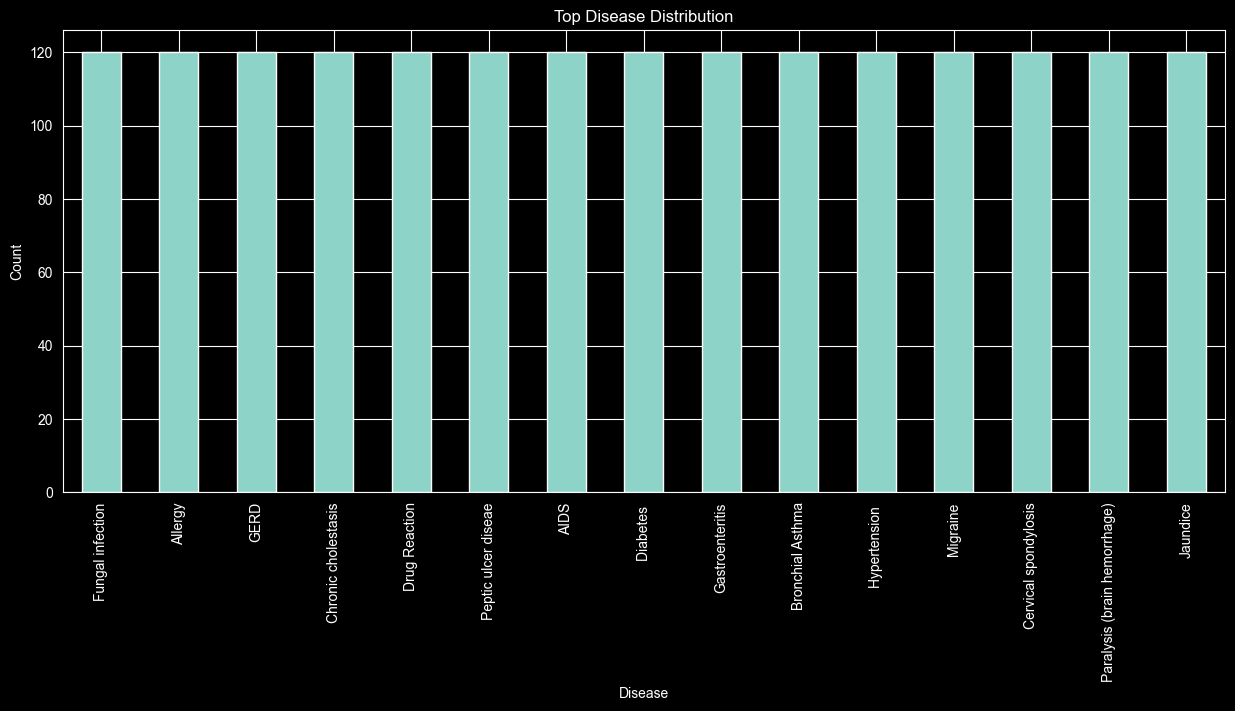

In [7]:
plt.figure(figsize=(15,6))

train_df['prognosis'].value_counts().head(15).plot(
    kind='bar'
)

plt.title("Top Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.show()

### Inference

The dataset contains multiple disease classes.

The distribution is reasonably balanced across disease categories.

# 5. Data Preparation

In [8]:
# 5. Data Preparation

X_train = train_df.drop("prognosis", axis=1)
y_train = train_df["prognosis"]

X_test = test_df.drop("prognosis", axis=1)
y_test = test_df["prognosis"]

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_test_encoded = label_encoder.transform(y_test)

print("Number of Disease Classes:", len(label_encoder.classes_))

print("Training Records:", X_train.shape)
print("Testing Records :", X_test.shape)

Number of Disease Classes: 41
Training Records: (4920, 132)
Testing Records : (42, 132)


# 6. Model Development

In [9]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train_encoded)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(
    y_test_encoded,
    lr_pred
)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 1.0


In [10]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train_encoded)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test_encoded,
    rf_pred
)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9761904761904762


In [11]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train_encoded)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(
    y_test_encoded,
    xgb_pred
)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.9761904761904762


In [12]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        lr_acc,
        rf_acc,
        xgb_acc
    ]
})

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,1.00000
1,Random Forest,0.97619
2,XGBoost,0.97619


### Observation

Comparative evaluation was performed to identify the most suitable model for the healthcare triage assistant.

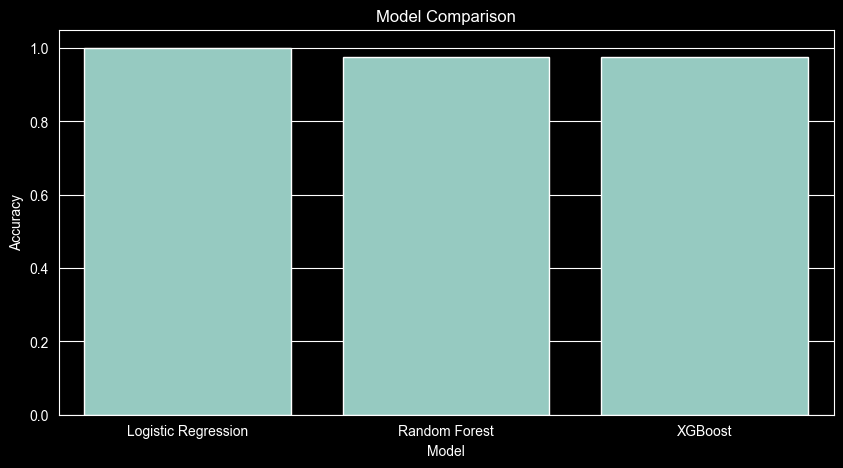

In [13]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Comparison")
plt.show()

# 7. Model Evaluation

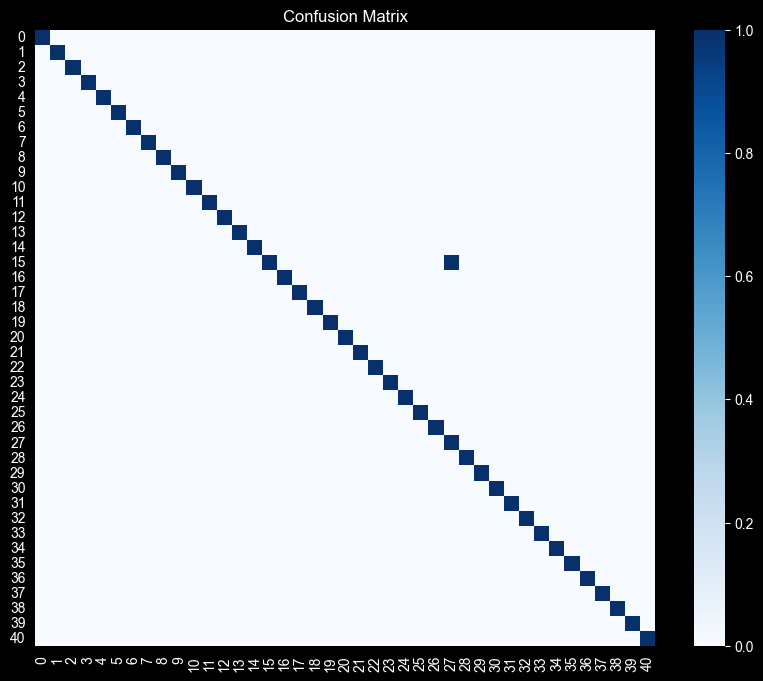

In [14]:
cm = confusion_matrix(
    y_test_encoded,
    rf_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [15]:
print(
    classification_report(
        y_test_encoded,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      0.50      0.67         2
          16       1.00      1.00      1.00         1
          17       1.00    

# 8. Explainable AI – Feature Importance

In [17]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
97,muscle_pain,0.019514
0,itching,0.016854
33,dark_urine,0.015853
25,high_fever,0.015595
98,altered_sensorium,0.014875
14,fatigue,0.014580
34,nausea,0.014471
41,mild_fever,0.014310
43,yellowing_of_eyes,0.014072
106,family_history,0.013757


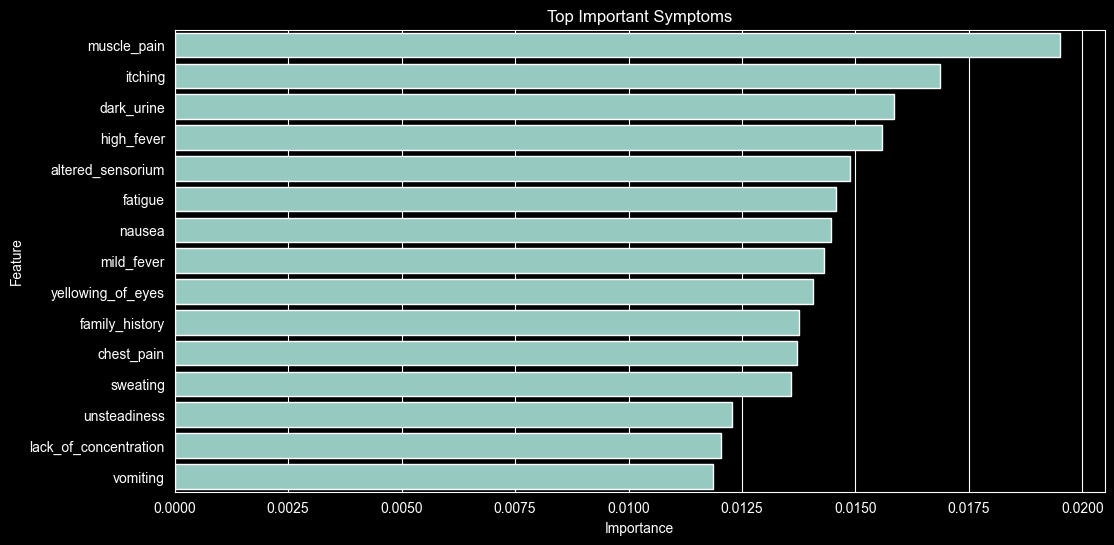

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top Important Symptoms")
plt.show()

### Interpretation

Feature importance analysis provides transparency regarding the symptom indicators influencing disease prediction.

This supports Explainable AI requirements in healthcare applications.

In [19]:
def risk_category(disease):

    high_risk = [
        "Heart attack",
    "Pneumonia",
    "Tuberculosis",
    "AIDS",
    "Hepatitis B",
    "Hepatitis C",
    "Hepatitis D",
    "Hepatitis E"
    ]

    medium_risk = [
        "Diabetes",
    "Hypertension",
    "Typhoid",
    "Dengue",
    "Malaria"
    ]

    if disease in high_risk:
        return "High Risk"

    elif disease in medium_risk:
        return "Medium Risk"

    else:
        return "Low Risk"

In [20]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

predicted_disease = label_encoder.inverse_transform(prediction)[0]

risk = risk_category(predicted_disease)

print("Predicted Disease :", predicted_disease)
print("Risk Category     :", risk)

Predicted Disease : Fungal infection
Risk Category     : Low Risk


# 9. Model Serialization

In [21]:
joblib.dump(
    rf,
    "../models/rf_model.pkl"
)

joblib.dump(
    label_encoder,
    "../models/label_encoder.pkl"
)

print("Artifacts Saved Successfully")

Artifacts Saved Successfully


In [23]:
emisclassified = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(y_test_encoded),
    "Predicted": label_encoder.inverse_transform(rf_pred)
})

misclassified[
    misclassified["Actual"] != misclassified["Predicted"]
]

,Actual,Predicted
41,Fungal infection,Impetigo


# 10. Conclusion

The preliminary implementation demonstrates the feasibility of a lightweight healthcare triage assistant capable of disease prediction and healthcare risk categorization using symptom-based indicators.

The developed solution forms the foundation for future multimodal healthcare extensions involving image and audio inputs.

# 11. Future Scope

Future enhancements include:

- Image-based healthcare analysis
- Audio and cough analysis
- Mobile deployment
- Regional language support
- LLM-assisted healthcare guidance
- Fully multimodal healthcare triage system